# KTAPPI text mining workflow

This notebook reproduces the keyword cleaning, keyword evolution, co-occurrence network, LDA topic modeling, topic dynamics, and citation-impact analyses for Scopus-indexed *Journal of Korea TAPPI* articles.

The notebook is organized for GitHub use:
- figures are displayed directly in each cell with `plt.show()`;
- tables are displayed with `display()`;
- file export is optional through `SAVE_OUTPUTS`;
- the input data path is relative to the repository root.

In [1]:
%matplotlib inline

from pathlib import Path
from collections import Counter
from itertools import combinations
import ast
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from matplotlib.ticker import MaxNLocator, MultipleLocator, FormatStrFormatter
from matplotlib.lines import Line2D

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

warnings.filterwarnings("ignore")

# ============================================================
# Repository configuration
# ============================================================

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "scopus_ktappi_2000_2025.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

SAVE_OUTPUTS = False  # Set True to export CSV tables and PNG figures.

if SAVE_OUTPUTS:
    RESULTS_DIR.mkdir(exist_ok=True)
    FIGURES_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
FINAL_N_TOPICS = 12
TOPIC_RANGE = range(2, 41)  # Use range(2, 41) for the full manuscript-style evaluation.

plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.linewidth"] = 0.9
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"
plt.rcParams["figure.dpi"] = 130

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)

Project root: c:\Users\user\Downloads\KTAPPI-text-mining-github-ready\KTAPPI-text-mining
Data path: c:\Users\user\Downloads\KTAPPI-text-mining-github-ready\KTAPPI-text-mining\data\scopus_ktappi_2000_2025.csv


## 1. Load Scopus metadata

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cannot find input data file: {DATA_PATH}\n"
        "Place the Scopus export file in data/scopus_ktappi_2000_2025.csv"
    )

df_raw = pd.read_csv(DATA_PATH)
print("Raw data shape:", df_raw.shape)
display(df_raw.head())
display(pd.DataFrame({"column": df_raw.columns}))

Raw data shape: (1583, 29)


,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,Funding Details,Funding Texts,Correspondence Address,ISSN,ISBN,CODEN,Language of Original Document,Document Type,Source,EID
0,Kim H.-N.; Choi B.-U.,"Kim, Ha-Neul (60433816300); Choi, Byoung-Uk (6...",60433816300; 60433816400,Effect of Drying Temperature on Network Struct...,2026,Palpu Chongi Gisul/Journal of Korea Technical ...,58,1,NaN,93,...,NaN,NaN,B.-U. Choi; Program of Paper Material Science ...,2533200,NaN,PCGID,English,Article,Scopus,2-s2.0-105031711591
1,Jo H.M.; Lee S.H.; Lee J.Y.,"Jo, Hae Min (57193554131); Lee, Soo Hyun (5791...",57193554131; 57913231300; 55900922000,Fundamental Study on Highly Transparent Films ...,2023,Palpu Chongi Gisul/Journal of Korea Technical ...,55,6,NaN,109,...,NaN,NaN,J.Y. Lee; Department of Environmental Material...,2533200,NaN,PCGID,Korean,Article,Scopus,2-s2.0-85182523012
2,Jo H.M.; Kim D.H.; Lee S.H.; Lee J.Y.; Park R.S.,"Jo, Hae Min (57193554131); Kim, Do Hoon (57912...",57193554131; 57912581700; 57913231300; 5590092...,Development of Domestic Taylor-flow Nanogrinde...,2022,Palpu Chongi Gisul/Journal of Korea Technical ...,54,5,NaN,5,...,NaN,NaN,J.Y. Lee; Department of Environmental Material...,2533200,NaN,PCGID,Korean,Article,Scopus,2-s2.0-85145357527
3,Kweon S.W.; Lee Y.J.; Kang N.Y.; Lee A.Y.; Kim...,"Kweon, Soon Wan (58529228500); Lee, Yong Ju (5...",58529228500; 57221979800; 58249474700; 5881638...,Identification of Mulberry Bast Fiber Using a ...,2023,Palpu Chongi Gisul/Journal of Korea Technical ...,55,6,NaN,59,...,NaN,NaN,H.J. Kim; Dept. of Forest Products & Biotechno...,2533200,NaN,PCGID,Korean,Article,Scopus,2-s2.0-85182523497
4,Oh K.; Sung Y.J.; Lee H.L.,"Oh, Kyudeok (55214343000); Sung, Yong Joo (234...",55214343000; 23471266700; 56329987200,Properties of Coated Paper Containing Cellulos...,2022,Palpu Chongi Gisul/Journal of Korea Technical ...,54,5,NaN,23,...,"National Natural Science Foundation of China, ...",This work was supported by the National Natural,"K. Oh; Department of Biobased Materials, Colle...",2533200,NaN,PCGID,Korean,Article,Scopus,2-s2.0-85145354499


,column
0,Authors
1,Author full names
2,Author(s) ID
3,Title
4,Year
5,Source title
6,Volume
7,Issue
8,Art. No.
9,Page start


In [3]:
# ============================================================
# Basic filtering
# ============================================================

df = df_raw.copy()

required = ["Title", "Year"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Year"]).copy()
df["Year"] = df["Year"].astype(int)

if "Cited by" in df.columns:
    df["Cited by"] = pd.to_numeric(df["Cited by"], errors="coerce").fillna(0)
else:
    df["Cited by"] = 0

if "Document Type" in df.columns:
    df = df[df["Document Type"].isin(["Article", "Review"])].copy()

df = df[(df["Year"] >= 2000) & (df["Year"] <= 2025)].copy()

print("Analysis data shape:", df.shape)
print("Year range:", df["Year"].min(), "-", df["Year"].max())

if "Document Type" in df.columns:
    display(df["Document Type"].value_counts().to_frame("n"))

Analysis data shape: (1571, 29)
Year range: 2000 - 2025


,n
Document Type,
Article,1535
Review,36


## 2. Keyword cleaning and synonym merging

In [4]:
# ============================================================
# Keyword cleaning dictionaries
# ============================================================

remove_keywords = {
    "paper", "papers", "pulp", "pulps", "cellulose", "fiber", "fibers",
    "wood", "material", "materials", "product", "products", "surface",
    "water", "strength", "property", "properties", "process", "processes",
    "article", "articles", "study", "studies", "result", "results",
    "analysis", "method", "methods", "experiment", "experiments",
    "evaluation", "comparison", "condition", "conditions", "mechanical",
    "efficiency", "performance", "formation", "handsheet", "handsheets",
    "hardwood", "hardwoods", "softwood", "softwoods", "manufacture",
    "fiber length", "paper and pulp industry", "paper and pulp mills"
}

synonym_map = {
    # Spectroscopy
    "ir spectroscopy": "infrared spectroscopy",
    "ftir spectroscopy": "infrared spectroscopy",
    "ft ir spectroscopy": "infrared spectroscopy",
    "fourier transform infrared spectroscopy": "infrared spectroscopy",
    "nir": "near infrared spectroscopy",
    "nir spectroscopy": "near infrared spectroscopy",
    "raman": "raman spectroscopy",
    "raman spectra": "raman spectroscopy",

    # Chemometrics and machine learning
    "pca": "principal component analysis",
    "principal components analysis": "principal component analysis",
    "plsr": "partial least squares regression",
    "partial least square regression": "partial least squares regression",
    "partial least squares": "partial least squares regression",
    "svm": "support vector machine",
    "support vector machines": "support vector machine",
    "random forests": "random forest",
    "ml": "machine learning",

    # Hanji
    "traditional korean paper": "hanji",
    "traditional korean papers": "hanji",
    "korean traditional paper": "hanji",
    "korean traditional papers": "hanji",
    "hanji paper": "hanji",

    # CMC and derivatives
    "cmc": "carboxymethyl cellulose",
    "carboxymethylcellulose": "carboxymethyl cellulose",
    "carboxy methyl cellulose": "carboxymethyl cellulose",
    "hydrogels": "hydrogel",
    "cellulose films": "cellulose film",

    # Papermaking / pulping
    "paper making": "papermaking",
    "beating": "refining",
    "pulp beating": "refining",
    "pulp refining": "refining",
    "kraft pulps": "kraft pulp",
    "bleached kraft pulps": "bleached kraft pulp",

    # Wet-end and coating
    "wet end": "wet-end chemistry",
    "wet end chemistry": "wet-end chemistry",
    "wet end chemistries": "wet-end chemistry",
    "flocculation": "wet-end chemistry",
    "surfactants": "wet-end chemistry",
    "surface active agents": "wet-end chemistry",
    "coating": "coatings",
    "filler": "fillers",
    "coated papers": "coated paper",

    # Sustainability / packaging
    "eco friendly": "eco-friendly",
    "environmentally friendly": "eco-friendly",
    "packaging materials": "packaging",
    "package": "packaging",

    # Optical
    "brightness": "optical properties",
    "luminance": "optical properties",
}

nanocellulose_patterns = [
    r"\bnano\s*cellulose\b",
    r"\bnanocellulose\b",
    r"\bnanocellulosic\b",
    r"\bcellulose\s+nano\s*materials?\b",
    r"\bcellulose\s+nanomaterials?\b",
    r"\bcellulose\s+based\s+nano\s*materials?\b",
    r"\bnano\s*fibrils?\b",
    r"\bnanofibrils?\b",
    r"\bcellulose\s+nano\s*fibrils?\b",
    r"\bcellulose\s+nanofibrils?\b",
    r"\bnano\s*fibrillated\s+cellulose\b",
    r"\bnanofibrillated\s+cellulose\b",
    r"\bmicro\s*fibrillated\s+cellulose\b",
    r"\bmicrofibrillated\s+cellulose\b",
    r"\bnano\s*fibers?\b",
    r"\bnanofibers?\b",
    r"\bcellulose\s+nano\s*fibers?\b",
    r"\bcellulose\s+nanofibers?\b",
    r"\bnano\s*crystals?\b",
    r"\bnanocrystals?\b",
    r"\bcellulose\s+nano\s*crystals?\b",
    r"\bcellulose\s+nanocrystals?\b",
    r"\bnano\s*whiskers?\b",
    r"\bnanowhiskers?\b",
    r"\bcellulose\s+nano\s*whiskers?\b",
    r"\bcellulose\s+nanowhiskers?\b",
    r"\bcnfs?\b",
    r"\bcncs?\b",
    r"\bmfc\b",
]

def normalize_keyword(keyword):
    if pd.isna(keyword):
        return None

    kw = str(keyword).lower().strip()
    kw = kw.replace("–", "-").replace("—", "-").replace("−", "-")
    kw = re.sub(r"\([^)]*\)", "", kw)
    kw = re.sub(r"[-/]", " ", kw)
    kw = re.sub(r"[^a-z0-9\s]", " ", kw)
    kw = re.sub(r"\s+", " ", kw).strip()

    for pat in nanocellulose_patterns:
        if re.search(pat, kw):
            kw = "nanocellulose"
            break

    kw = synonym_map.get(kw, kw)
    kw = re.sub(r"\s+", " ", kw).strip()

    if kw in remove_keywords:
        return None
    if len(kw) <= 2:
        return None

    return kw

def split_keywords(keyword_text):
    if pd.isna(keyword_text) or str(keyword_text).strip() == "":
        return []

    parts = re.split(r";", str(keyword_text))
    kws = []
    for p in parts:
        kw = normalize_keyword(p)
        if kw is not None:
            kws.append(kw)

    return sorted(set(kws))

def assign_period(year):
    if year <= 2009:
        return "2000-2009"
    elif year <= 2015:
        return "2010-2015"
    elif year <= 2020:
        return "2016-2020"
    else:
        return "2021-2025"

def clean_label(text):
    text = str(text).replace("_", " ").strip()
    return text[0].upper() + text[1:] if text else text

In [5]:
for col in ["Author Keywords", "Index Keywords", "Abstract"]:
    if col not in df.columns:
        df[col] = ""

df["Author Keywords"] = df["Author Keywords"].fillna("")
df["Index Keywords"] = df["Index Keywords"].fillna("")
df["Abstract"] = df["Abstract"].fillna("")
df["Title"] = df["Title"].fillna("")

df["author_keyword_list"] = df["Author Keywords"].apply(split_keywords)
df["index_keyword_list"] = df["Index Keywords"].apply(split_keywords)
df["refined_keyword_list"] = (
    df["author_keyword_list"] + df["index_keyword_list"]
).apply(lambda x: sorted(set(x)))

df["Period"] = df["Year"].apply(assign_period)

# Nanocellulose merge check
all_keywords = pd.Series([kw for kws in df["refined_keyword_list"] for kw in kws])
residual_nano = all_keywords[
    all_keywords.str.contains(
        "nanofibril|nano fibril|nanofiber|nano fiber|cnf|cnc|nanocrystal|nano crystal|nanomaterial|nanowhisker|mfc",
        case=False,
        na=False
    )
].value_counts()

print("Residual nanocellulose-related terms after merging:")
display(residual_nano)

nanocellulose_doc_freq = sum("nanocellulose" in set(kws) for kws in df["refined_keyword_list"])
print("Nanocellulose document frequency:", nanocellulose_doc_freq, f"({nanocellulose_doc_freq / len(df) * 100:.2f}%)")

if SAVE_OUTPUTS:
    df.to_csv(RESULTS_DIR / "clean_refined_dataset.csv", index=False, encoding="utf-8-sig")

Residual nanocellulose-related terms after merging:


nano fibrillations           5
nanocrystalline materials    1
nanofibrillation             1
nano fibrillation energy     1
Name: count, dtype: int64

Nanocellulose document frequency: 153 (9.74%)


## 3. Dataset summary

In [6]:
summary = pd.DataFrame({
    "Item": [
        "Analysis period",
        "Number of documents",
        "Document types",
        "Source title",
        "Keyword fields",
        "Citation field"
    ],
    "Value": [
        f"{df['Year'].min()}–{df['Year'].max()}",
        len(df),
        ", ".join(df["Document Type"].dropna().unique()) if "Document Type" in df.columns else "Not available",
        df["Source title"].dropna().iloc[0] if "Source title" in df.columns and df["Source title"].notna().any() else "Journal of Korea TAPPI",
        "Author Keywords; Index Keywords",
        "Cited by"
    ]
})

display(summary)

annual_summary = (
    df.groupby("Year")
    .agg(
        publications=("Title", "count"),
        citations=("Cited by", "sum")
    )
    .reset_index()
)

display(annual_summary.head())

if SAVE_OUTPUTS:
    summary.to_csv(RESULTS_DIR / "dataset_summary.csv", index=False, encoding="utf-8-sig")
    annual_summary.to_csv(RESULTS_DIR / "annual_publication_citation_summary.csv", index=False, encoding="utf-8-sig")

,Item,Value
0,Analysis period,2000–2025
1,Number of documents,1571
2,Document types,"Article, Review"
3,Source title,Palpu Chongi Gisul/Journal of Korea Technical ...
4,Keyword fields,Author Keywords; Index Keywords
5,Citation field,Cited by


,Year,publications,citations
0,2000,40,73
1,2001,39,63
2,2002,50,90
3,2003,32,72
4,2004,51,117


## 4. Publication and citation trend

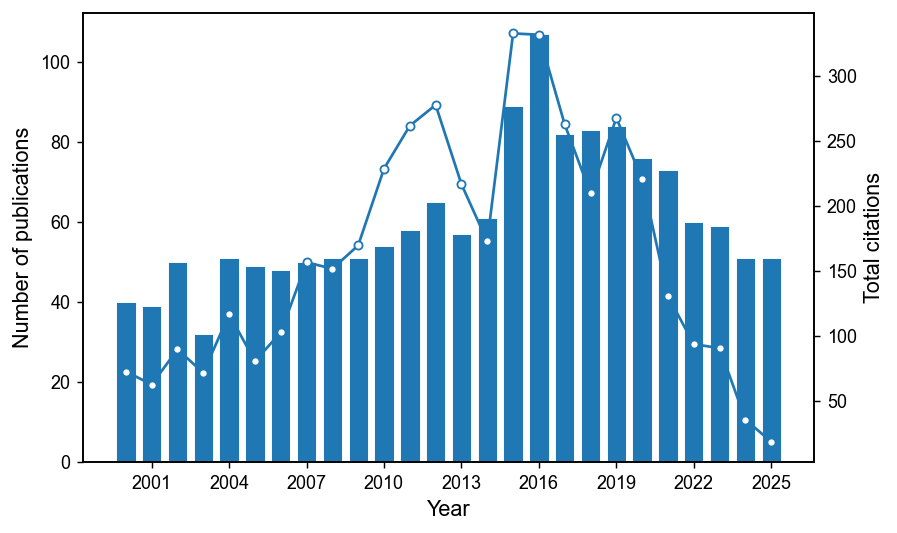

In [7]:
fig, ax1 = plt.subplots(figsize=(7.0, 4.2))

ax1.bar(
    annual_summary["Year"],
    annual_summary["publications"],
    width=0.75,
    edgecolor="white",
    linewidth=0.5
)
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Number of publications", fontsize=12)
ax1.tick_params(axis="both", labelsize=10)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

ax2 = ax1.twinx()
ax2.plot(
    annual_summary["Year"],
    annual_summary["citations"],
    marker="o",
    markersize=4.5,
    markerfacecolor="white",
    linewidth=1.5
)
ax2.set_ylabel("Total citations", fontsize=12)
ax2.tick_params(axis="y", labelsize=10)

ax1.spines["top"].set_visible(True)
ax2.spines["top"].set_visible(True)

plt.tight_layout()
if SAVE_OUTPUTS:
    plt.savefig(FIGURES_DIR / "fig_publication_citation_trend.png", dpi=600, bbox_inches="tight")
plt.show()

## 5. Keyword frequency and keyword evolution

In [8]:
# Overall keyword frequency
keyword_counter = Counter()
for kws in df["refined_keyword_list"]:
    keyword_counter.update(set(kws))

overall_kw = pd.DataFrame(
    [{"keyword": k, "document_occurrence": v, "document_percent": v / len(df) * 100}
     for k, v in keyword_counter.items()]
).sort_values("document_occurrence", ascending=False).reset_index(drop=True)

overall_kw.insert(0, "rank", range(1, len(overall_kw) + 1))

print("Overall top refined keywords")
display(overall_kw.head(30))

# Period keyword frequency
period_rows = []
for period, sub in df.groupby("Period"):
    n = len(sub)
    counter = Counter()
    for kws in sub["refined_keyword_list"]:
        counter.update(set(kws))
    for kw, occ in counter.items():
        period_rows.append({
            "Period": period,
            "keyword": kw,
            "document_occurrence": occ,
            "period_total_documents": n,
            "period_proportion": occ / n,
            "period_percent": occ / n * 100
        })

period_kw = pd.DataFrame(period_rows)

period_top = (
    period_kw.sort_values(["Period", "document_occurrence"], ascending=[True, False])
    .groupby("Period")
    .head(10)
    .copy()
)
period_top["rank"] = period_top.groupby("Period").cumcount() + 1

print("Period-specific top refined keywords")
display(period_top[["Period", "rank", "keyword", "document_occurrence", "period_percent"]])

if SAVE_OUTPUTS:
    overall_kw.to_csv(RESULTS_DIR / "overall_refined_keyword_frequency.csv", index=False, encoding="utf-8-sig")
    period_kw.to_csv(RESULTS_DIR / "period_refined_keyword_frequency.csv", index=False, encoding="utf-8-sig")
    period_top.to_csv(RESULTS_DIR / "period_top_keywords.csv", index=False, encoding="utf-8-sig")

Overall top refined keywords


,rank,keyword,document_occurrence,document_percent
0,1,tensile strength,172,10.948440
1,2,papermaking,162,10.311903
2,3,nanocellulose,153,9.739020
3,4,kraft pulp,148,9.420751
4,5,optical properties,139,8.847868
5,6,coatings,111,7.065563
6,7,refining,108,6.874602
7,8,recycling,99,6.301719
8,9,starch,96,6.110757
9,10,lignin,94,5.983450


Period-specific top refined keywords


,Period,rank,keyword,document_occurrence,period_percent
5,2000-2009,1,papermaking,69,14.967462
13,2000-2009,2,recycling,50,10.845987
30,2000-2009,3,ink,34,7.375271
209,2000-2009,4,tensile strength,34,7.375271
163,2000-2009,5,starch,33,7.158351
25,2000-2009,6,paper coating,31,6.724512
240,2000-2009,7,waste paper,28,6.073753
262,2000-2009,8,refining,28,6.073753
89,2000-2009,9,newsprint,27,5.856833
269,2000-2009,10,kraft pulp,27,5.856833


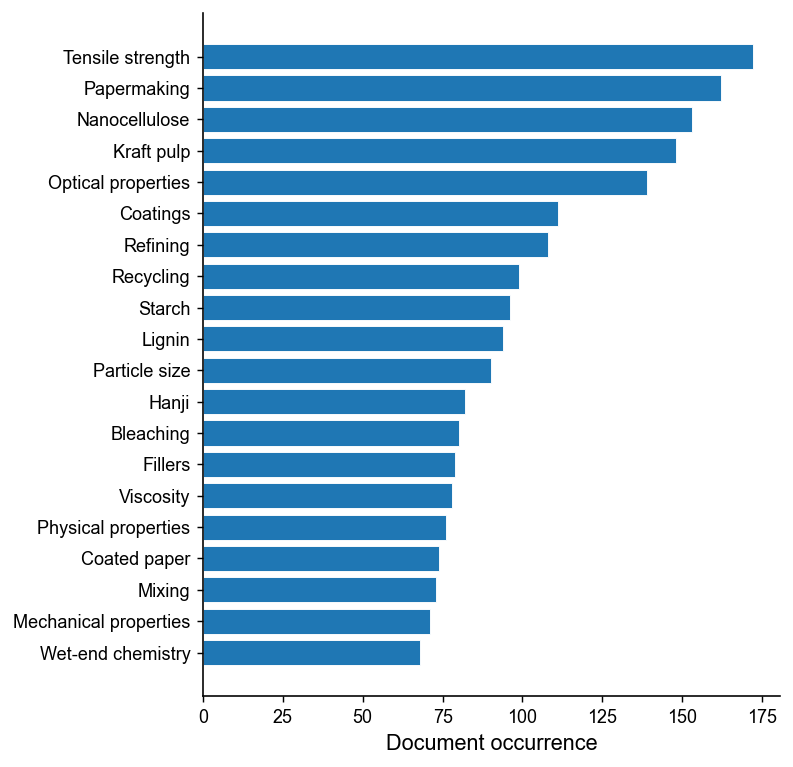

In [9]:
# Overall top keyword plot
top_n = 20
plot_df = overall_kw.head(top_n).sort_values("document_occurrence", ascending=True).copy()
plot_df["label"] = plot_df["keyword"].apply(clean_label)

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.barh(plot_df["label"], plot_df["document_occurrence"], edgecolor="white", linewidth=0.5)
ax.set_xlabel("Document occurrence", fontsize=12)
ax.tick_params(axis="both", labelsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
if SAVE_OUTPUTS:
    plt.savefig(FIGURES_DIR / "fig_overall_top_keywords.png", dpi=600, bbox_inches="tight")
plt.show()

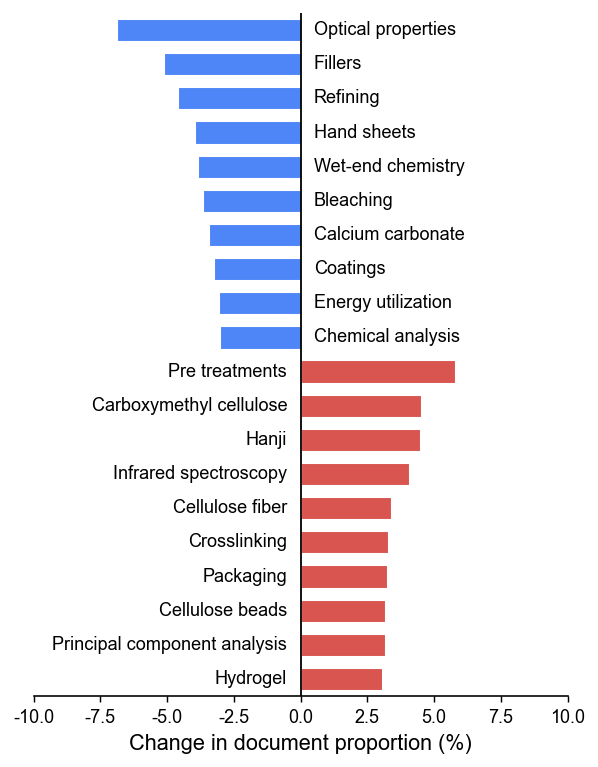

Period,keyword,keyword_label,2016-2020,2021-2025,change_percent
0,optical properties,Optical properties,0.092593,0.023810,-6.878307
1,fillers,Fillers,0.064815,0.013605,-5.120937
2,refining,Refining,0.083333,0.037415,-4.591837
3,hand sheets,Hand sheets,0.039352,0.000000,-3.935185
4,wet-end chemistry,Wet-end chemistry,0.048611,0.010204,-3.840703
5,bleaching,Bleaching,0.067130,0.030612,-3.651738
6,calcium carbonate,Calcium carbonate,0.064815,0.030612,-3.420257
7,coatings,Coatings,0.097222,0.064626,-3.259637
8,energy utilization,Energy utilization,0.043981,0.013605,-3.037604
9,chemical analysis,Chemical analysis,0.037037,0.006803,-3.023432


In [10]:
# Recently increasing/decreasing keywords: 2016–2020 vs 2021–2025
pivot = period_kw.pivot_table(
    index="keyword",
    columns="Period",
    values="period_proportion",
    fill_value=0
).reset_index()

for p in ["2000-2009", "2010-2015", "2016-2020", "2021-2025"]:
    if p not in pivot.columns:
        pivot[p] = 0

pivot["growth_recent"] = pivot["2021-2025"] - pivot["2016-2020"]
pivot["change_percent"] = pivot["growth_recent"] * 100
pivot["keyword_label"] = pivot["keyword"].apply(clean_label)

top_n = 10
declining = (
    pivot[pivot["growth_recent"] < 0]
    .sort_values("growth_recent", ascending=True)
    .head(top_n)
    .copy()
)
emerging = (
    pivot[pivot["growth_recent"] > 0]
    .sort_values("growth_recent", ascending=False)
    .head(top_n)
    .copy()
)

fig3_data = pd.concat(
    [
        declining.sort_values("change_percent", ascending=True),
        emerging.sort_values("change_percent", ascending=False)
    ],
    ignore_index=True
)
fig3_data["y_pos"] = range(len(fig3_data))
fig3_data["color"] = fig3_data["change_percent"].apply(lambda x: "#d95550" if x > 0 else "#4f86f7")

fig, ax = plt.subplots(figsize=(4.7, 6.0))
ax.barh(
    fig3_data["y_pos"],
    fig3_data["change_percent"],
    color=fig3_data["color"],
    edgecolor="white",
    linewidth=0.6,
    height=0.65
)
ax.axvline(0, color="black", linewidth=1.0)
ax.set_xlim(-10.0, 10.0)
ax.xaxis.set_major_locator(MultipleLocator(2.5))
ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
ax.set_ylim(-0.5, len(fig3_data) - 0.5)
ax.set_yticks([])
ax.set_xlabel("Change in document proportion (%)", fontsize=12)

for _, row in fig3_data.iterrows():
    if row["change_percent"] > 0:
        ax.text(-0.5, row["y_pos"], row["keyword_label"], va="center", ha="right", fontsize=10)
    else:
        ax.text(0.5, row["y_pos"], row["keyword_label"], va="center", ha="left", fontsize=10)

ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.tight_layout()
if SAVE_OUTPUTS:
    plt.savefig(FIGURES_DIR / "fig_recent_keyword_change.png", dpi=600, bbox_inches="tight")
plt.show()

display(fig3_data[["keyword", "keyword_label", "2016-2020", "2021-2025", "change_percent"]])

if SAVE_OUTPUTS:
    fig3_data.to_csv(RESULTS_DIR / "recent_keyword_change_fig3_data.csv", index=False, encoding="utf-8-sig")

## 6. Keyword co-occurrence network and centrality

In [11]:
min_doc_frequency = 10
min_edge_weight = 3

valid_keywords = set(overall_kw[overall_kw["document_occurrence"] >= min_doc_frequency]["keyword"])

edge_counter = Counter()
for kws in df["refined_keyword_list"]:
    kws_valid = sorted(set(kws) & valid_keywords)
    for kw1, kw2 in combinations(kws_valid, 2):
        edge_counter[(kw1, kw2)] += 1

edges = pd.DataFrame(
    [{"source": s, "target": t, "weight": w}
     for (s, t), w in edge_counter.items() if w >= min_edge_weight]
).sort_values("weight", ascending=False).reset_index(drop=True)

G = nx.Graph()
for _, row in overall_kw[overall_kw["keyword"].isin(valid_keywords)].iterrows():
    G.add_node(
        row["keyword"],
        document_frequency=int(row["document_occurrence"]),
        document_percent=float(row["document_percent"])
    )

for _, row in edges.iterrows():
    G.add_edge(row["source"], row["target"], weight=float(row["weight"]))

G.remove_nodes_from(list(nx.isolates(G)))

print("Network threshold: min_doc_frequency >=", min_doc_frequency, ", min_edge_weight >=", min_edge_weight)
print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())

degree_centrality = nx.degree_centrality(G)
weighted_degree = dict(G.degree(weight="weight"))

for u, v, data in G.edges(data=True):
    data["distance"] = 1 / data["weight"]

betweenness_centrality = nx.betweenness_centrality(G, weight="distance", normalized=True)

try:
    eigenvector_centrality = nx.eigenvector_centrality(G, weight="weight", max_iter=1000, tol=1e-06)
except Exception:
    eigenvector_centrality = nx.eigenvector_centrality_numpy(G, weight="weight")

centrality = pd.DataFrame([
    {
        "keyword": node,
        "document_frequency": G.nodes[node]["document_frequency"],
        "document_percent": G.nodes[node]["document_percent"],
        "degree": G.degree(node),
        "weighted_degree": weighted_degree[node],
        "degree_centrality": degree_centrality[node],
        "betweenness_centrality": betweenness_centrality[node],
        "eigenvector_centrality": eigenvector_centrality[node]
    }
    for node in G.nodes()
]).sort_values(["weighted_degree", "document_frequency"], ascending=False).reset_index(drop=True)

communities = nx.algorithms.community.greedy_modularity_communities(G, weight="weight")
community_map = {}
for i, community in enumerate(communities, start=1):
    for node in community:
        community_map[node] = i

centrality["community_id"] = centrality["keyword"].map(community_map)

community_summary = (
    centrality
    .sort_values(["community_id", "weighted_degree"], ascending=[True, False])
    .groupby("community_id")
    .agg(
        n_keywords=("keyword", "count"),
        top_keywords=("keyword", lambda x: "; ".join(x.head(12))),
        top5_keywords=("keyword", lambda x: "; ".join(x.head(5)))
    )
    .reset_index()
)

print("Top central keywords")
display(centrality.head(30))

print("Community summary")
display(community_summary)

if SAVE_OUTPUTS:
    edges.to_csv(RESULTS_DIR / "keyword_network_edges.csv", index=False, encoding="utf-8-sig")
    centrality.to_csv(RESULTS_DIR / "keyword_network_centrality.csv", index=False, encoding="utf-8-sig")
    community_summary.to_csv(RESULTS_DIR / "keyword_network_community_summary.csv", index=False, encoding="utf-8-sig")

Network threshold: min_doc_frequency >= 10 , min_edge_weight >= 3
Graph nodes: 465
Graph edges: 3919
Top central keywords


,keyword,document_frequency,document_percent,degree,weighted_degree,degree_centrality,betweenness_centrality,eigenvector_centrality,community_id
0,tensile strength,172,10.948440,179,1067.0,0.385776,0.262756,0.269389,2
1,kraft pulp,148,9.420751,152,1036.0,0.327586,0.265120,0.325259,1
2,papermaking,162,10.311903,167,983.0,0.359914,0.250224,0.233896,2
3,nanocellulose,153,9.739020,140,940.0,0.301724,0.232314,0.250698,1
4,optical properties,139,8.847868,151,870.0,0.325431,0.161163,0.236987,2
5,coatings,111,7.065563,94,679.0,0.202586,0.149334,0.155424,4
6,refining,108,6.874602,109,640.0,0.234914,0.042328,0.200798,1
7,starch,96,6.110757,99,570.0,0.213362,0.068044,0.128093,2
8,particle size,90,5.728835,91,523.0,0.196121,0.036899,0.162146,1
9,recycling,99,6.301719,91,517.0,0.196121,0.091212,0.119503,5


Community summary


,community_id,n_keywords,top_keywords,top5_keywords
0,1,103,kraft pulp; nanocellulose; refining; particle ...,kraft pulp; nanocellulose; refining; particle ...
1,2,101,tensile strength; papermaking; optical propert...,tensile strength; papermaking; optical propert...
2,3,78,lignin; hanji; plants; bast fibers; paper mulb...,lignin; hanji; plants; bast fibers; paper mulb...
3,4,70,coatings; coated paper; mixing; color; surface...,coatings; coated paper; mixing; color; surface...
4,5,59,recycling; waste paper; corrugated containers;...,recycling; waste paper; corrugated containers;...
5,6,31,packaging; pulp materials; biomass; water abso...,packaging; pulp materials; biomass; water abso...
6,7,15,chlorine compounds; hydrophobicity; grafting; ...,chlorine compounds; hydrophobicity; grafting; ...
7,8,6,paper industries; paper industry; pulp industr...,paper industries; paper industry; pulp industr...
8,9,2,chemistry; materials science,chemistry; materials science


In [12]:
# Centrality table by metric
centrality_ranked = centrality.copy()
centrality_ranked["Keyword"] = centrality_ranked["keyword"].apply(clean_label)

top_n = 10
metrics = [
    ("degree_centrality", "Degree centrality"),
    ("betweenness_centrality", "Betweenness centrality"),
    ("eigenvector_centrality", "Eigenvector centrality")
]

table_parts = [pd.DataFrame({"Rank": range(1, top_n + 1)})]
for col, label in metrics:
    top_df = centrality_ranked.sort_values(col, ascending=False).head(top_n).reset_index(drop=True)
    table_parts.append(pd.DataFrame({
        f"{label} keyword": top_df["Keyword"],
        f"{label} score": top_df[col].round(3)
    }))

table3_centrality = pd.concat(table_parts, axis=1)
display(table3_centrality)

if SAVE_OUTPUTS:
    table3_centrality.to_csv(RESULTS_DIR / "table3_top10_centrality.csv", index=False, encoding="utf-8-sig")

,Rank,Degree centrality keyword,Degree centrality score,Betweenness centrality keyword,Betweenness centrality score,Eigenvector centrality keyword,Eigenvector centrality score
0,1,Tensile strength,0.386,Kraft pulp,0.265,Kraft pulp,0.325
1,2,Papermaking,0.360,Tensile strength,0.263,Tensile strength,0.269
2,3,Kraft pulp,0.328,Papermaking,0.250,Nanocellulose,0.251
3,4,Optical properties,0.325,Nanocellulose,0.232,Optical properties,0.237
4,5,Nanocellulose,0.302,Optical properties,0.161,Papermaking,0.234
5,6,Refining,0.235,Coatings,0.149,Bleaching,0.216
6,7,Starch,0.213,Lignin,0.107,Cleaning,0.205
7,8,Coatings,0.203,Recycling,0.091,Refining,0.201
8,9,Particle size,0.196,Starch,0.068,Bleached kraft pulp,0.192
9,10,Recycling,0.196,Hanji,0.055,Particle size,0.162


Displayed nodes: 120
Displayed edges: 1590


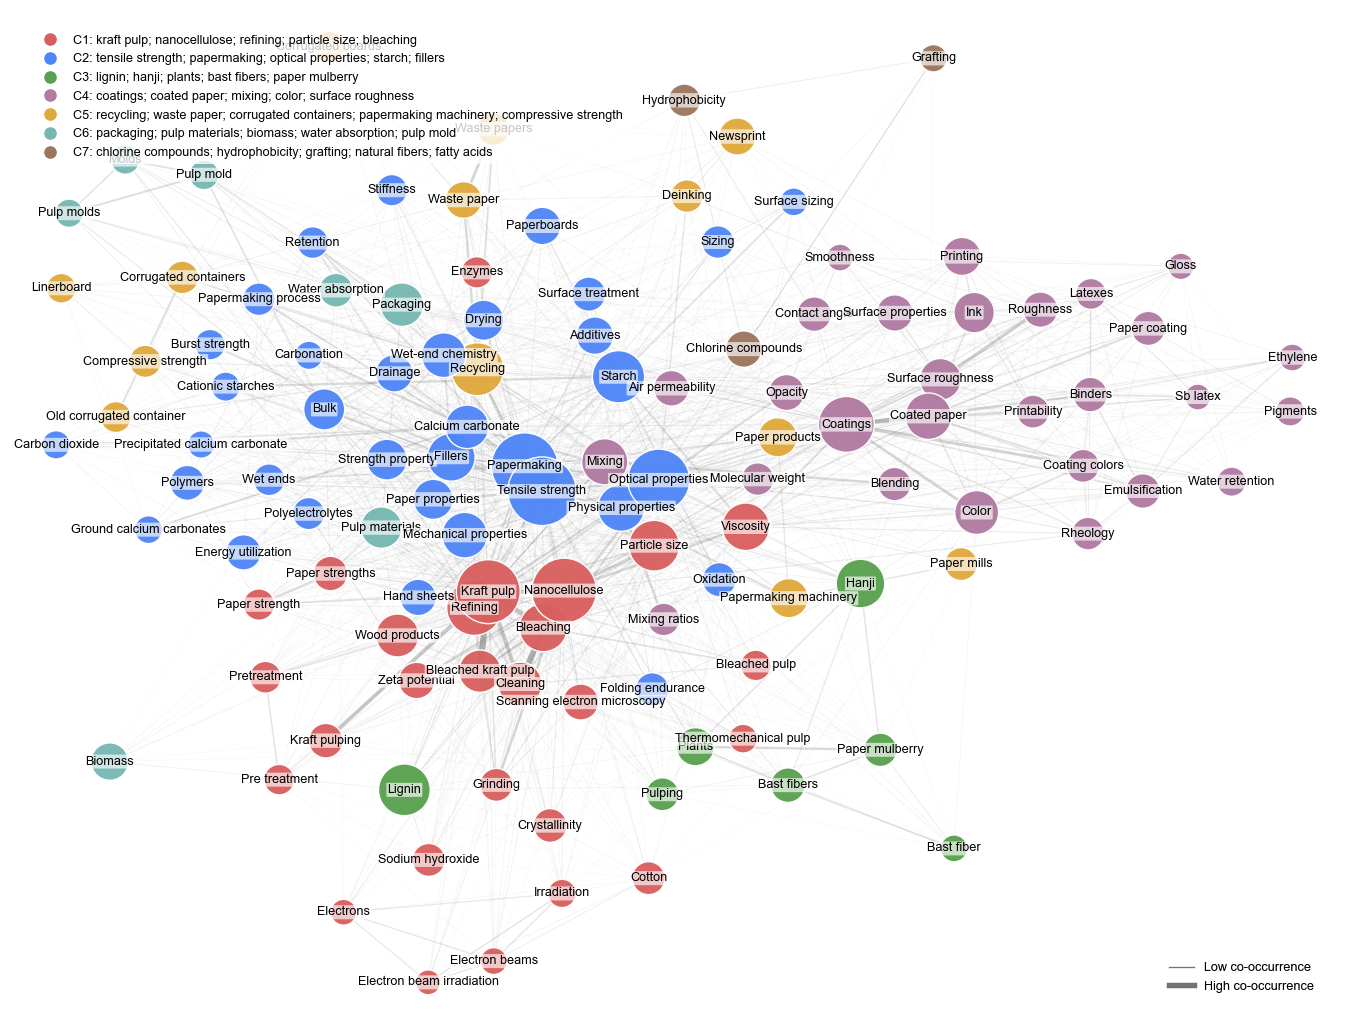

In [13]:
def make_palette(unique_communities):
    palette = [
        "#D95F5F", "#4F86F7", "#59A14F", "#B07AA1", "#E0A93B",
        "#76B7B2", "#9C755F", "#7E7F9A", "#F28E2B", "#8CD17D"
    ]
    return {cid: palette[i % len(palette)] for i, cid in enumerate(unique_communities)}

def show_network(G, centrality, community_summary, community_map, top_n_nodes_plot=120):
    top_nodes = centrality.head(top_n_nodes_plot)["keyword"].tolist()
    H = G.subgraph(top_nodes).copy()
    H.remove_nodes_from(list(nx.isolates(H)))

    print("Displayed nodes:", H.number_of_nodes())
    print("Displayed edges:", H.number_of_edges())

    pos = nx.spring_layout(H, weight="weight", seed=RANDOM_STATE, k=0.75, iterations=500)

    node_freq = nx.get_node_attributes(H, "document_frequency")
    node_sizes = [70 + node_freq[n] * 8 for n in H.nodes()]

    unique_communities = sorted({community_map[n] for n in H.nodes()})
    color_map = make_palette(unique_communities)
    node_colors = [color_map[community_map[n]] for n in H.nodes()]

    edge_weights = np.array([H[u][v]["weight"] for u, v in H.edges()], dtype=float)
    if len(edge_weights) > 0:
        min_w, max_w = edge_weights.min(), edge_weights.max()
    else:
        min_w, max_w = 1, 1

    edge_widths, edge_alphas = [], []
    for u, v in H.edges():
        w = H[u][v]["weight"]
        scaled = (w - min_w) / (max_w - min_w) if max_w > min_w else 0.5
        edge_widths.append(0.20 + scaled * 3.20)
        edge_alphas.append(0.10 + scaled * 0.60)

    labels = {n: clean_label(n) for n in H.nodes()}

    fig, ax = plt.subplots(figsize=(10.5, 8.0))
    fig.subplots_adjust(left=0.00, right=1.00, top=1.00, bottom=0.00)

    for (u, v), width, alpha in zip(H.edges(), edge_widths, edge_alphas):
        nx.draw_networkx_edges(H, pos, edgelist=[(u, v)], ax=ax, width=width, edge_color="0.55", alpha=alpha)

    nx.draw_networkx_nodes(
        H, pos, ax=ax, node_size=node_sizes, node_color=node_colors,
        edgecolors="white", linewidths=0.8, alpha=0.96
    )

    nx.draw_networkx_labels(
        H, pos, labels=labels, ax=ax, font_size=7.0,
        font_family="Arial", font_color="black",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, boxstyle="round,pad=0.08")
    )

    handles = []
    community_summary_plot = community_summary[
        community_summary["community_id"].isin(color_map.keys())
    ].sort_values("community_id")

    for _, row in community_summary_plot.head(8).iterrows():
        cid = int(row["community_id"])
        handles.append(
            Line2D([0], [0], marker="o", color="none",
                   label=f"C{cid}: {row['top5_keywords']}",
                   markerfacecolor=color_map[cid], markeredgecolor="white", markersize=8)
        )

    legend1 = ax.legend(
        handles=handles, loc="upper left", bbox_to_anchor=(0.01, 0.99),
        frameon=True, fontsize=7.0, framealpha=0.78, edgecolor="none"
    )
    ax.add_artist(legend1)

    edge_legend = [
        Line2D([0], [0], color="0.45", linewidth=0.7, label="Low co-occurrence"),
        Line2D([0], [0], color="0.45", linewidth=3.0, label="High co-occurrence")
    ]
    legend2 = ax.legend(
        handles=edge_legend, loc="lower right", bbox_to_anchor=(0.99, 0.01),
        frameon=True, fontsize=7.0, framealpha=0.78, edgecolor="none"
    )
    ax.add_artist(legend2)

    ax.set_axis_off()
    ax.margins(0.01)
    plt.tight_layout()
    if SAVE_OUTPUTS:
        plt.savefig(FIGURES_DIR / "fig_keyword_cooccurrence_network.png", dpi=600, bbox_inches="tight")
    plt.show()

    return H

H_display = show_network(G, centrality, community_summary, community_map, top_n_nodes_plot=120)

## 7. LDA topic modeling

In [14]:
# ============================================================
# Prepare topic modeling documents
# ============================================================

df["topic_text"] = df["refined_keyword_list"].apply(lambda kws: " ".join(kws))

# Fallback: if a document has no refined keywords, use title + abstract.
fallback_text = (df["Title"].fillna("") + " " + df["Abstract"].fillna("")).str.lower()
df.loc[df["topic_text"].str.strip() == "", "topic_text"] = fallback_text[df["topic_text"].str.strip() == ""]

vectorizer = CountVectorizer(
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z0-9_]{2,}\b",
    min_df=3,
    max_df=0.70,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df["topic_text"])
feature_names = np.array(vectorizer.get_feature_names_out())

print("Document-term matrix:", X.shape)

Document-term matrix: (1571, 4799)


,n_topics,perplexity,coherence
0,2,2006.068813,-1.880597
1,3,1929.304678,-1.897119
2,4,1807.678372,-1.789045
3,5,1810.703138,-1.975592
4,6,1787.632783,-1.901774


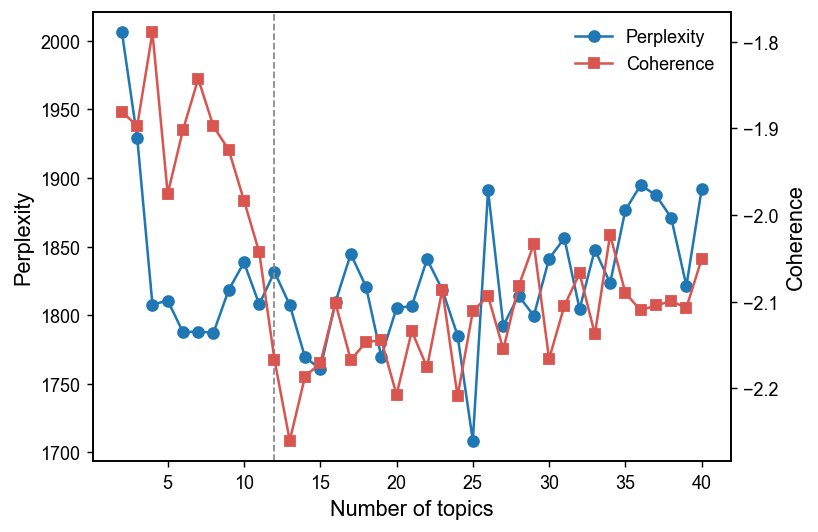

In [15]:
# ============================================================
# Topic number evaluation: perplexity and coherence
# ============================================================

def get_top_terms(model, feature_names, n_terms=15):
    topic_terms = []
    for topic_idx, comp in enumerate(model.components_):
        top_idx = comp.argsort()[::-1][:n_terms]
        topic_terms.append([feature_names[i] for i in top_idx])
    return topic_terms

def compute_umass_coherence(topic_terms, X, top_n=10, eps=1e-12):
    # Lightweight UMass-style coherence based on document co-occurrence.
    # This is included as a fallback when gensim is unavailable.
    X_bin = (X > 0).astype(int)
    term_to_col = {t: i for i, t in enumerate(feature_names)}
    scores = []
    for terms in topic_terms:
        cols = [term_to_col[t] for t in terms[:top_n] if t in term_to_col]
        if len(cols) < 2:
            continue
        topic_score = 0
        pairs = 0
        for m in range(1, len(cols)):
            for l in range(0, m):
                col_m, col_l = cols[m], cols[l]
                D_l = X_bin[:, col_l].sum()
                D_ml = X_bin[:, [col_m, col_l]].sum(axis=1)
                D_ml = np.asarray(D_ml).ravel()
                D_ml = (D_ml == 2).sum()
                topic_score += np.log((D_ml + 1) / (D_l + eps))
                pairs += 1
        if pairs > 0:
            scores.append(topic_score / pairs)
    return float(np.mean(scores)) if scores else np.nan

evaluation_rows = []

for n_topics in TOPIC_RANGE:
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        learning_method="batch",
        max_iter=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    lda.fit(X)

    perplexity = lda.perplexity(X)
    top_terms = get_top_terms(lda, feature_names, n_terms=15)
    coherence = compute_umass_coherence(top_terms, X, top_n=10)

    evaluation_rows.append({
        "n_topics": n_topics,
        "perplexity": perplexity,
        "coherence": coherence
    })

evaluation_df = pd.DataFrame(evaluation_rows)
display(evaluation_df.head())

fig, ax1 = plt.subplots(figsize=(6.4, 4.2))
ax1.plot(evaluation_df["n_topics"], evaluation_df["perplexity"], marker="o", linewidth=1.4, label="Perplexity")
ax1.set_xlabel("Number of topics", fontsize=12)
ax1.set_ylabel("Perplexity", fontsize=12)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.tick_params(labelsize=10)

ax2 = ax1.twinx()
ax2.plot(evaluation_df["n_topics"], evaluation_df["coherence"], marker="s", linewidth=1.4, color="#d95550", label="Coherence")
ax2.set_ylabel("Coherence", fontsize=12)
ax2.tick_params(labelsize=10)

ax1.axvline(FINAL_N_TOPICS, color="0.55", linestyle="--", linewidth=1.0)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, frameon=False, fontsize=10, loc="best")

plt.tight_layout()
if SAVE_OUTPUTS:
    plt.savefig(FIGURES_DIR / "fig_topic_number_evaluation.png", dpi=600, bbox_inches="tight")
    evaluation_df.to_csv(RESULTS_DIR / "topic_number_evaluation.csv", index=False, encoding="utf-8-sig")
plt.show()

In [16]:
# ============================================================
# Fit final LDA model
# ============================================================

lda_model = LatentDirichletAllocation(
    n_components=FINAL_N_TOPICS,
    learning_method="batch",
    max_iter=50,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
doc_topic_matrix = lda_model.fit_transform(X)
df["dominant_topic"] = doc_topic_matrix.argmax(axis=1) + 1
df["dominant_topic_probability"] = doc_topic_matrix.max(axis=1)

topic_terms = []
for topic_idx, comp in enumerate(lda_model.components_):
    top_idx = comp.argsort()[::-1][:20]
    terms = feature_names[top_idx]
    weights = comp[top_idx]
    for rank, (term, weight) in enumerate(zip(terms, weights), start=1):
        topic_terms.append({
            "topic_id": topic_idx + 1,
            "rank": rank,
            "term": term,
            "weight": weight
        })

topic_terms_df = pd.DataFrame(topic_terms)

# Manuscript-style labels can be edited after inspecting top terms.
DEFAULT_TOPIC_LABELS = {
    1: "Wet-end additives",
    2: "Refining and strength",
    3: "Drying and corrugated board",
    4: "Pulping and bleaching",
    5: "Recycling and drainage",
    6: "Surface sizing and adhesion",
    7: "Biomass and molded packaging",
    8: "Hanji and aging properties",
    9: "Nanocellulose materials",
    10: "Coating and printability",
    11: "Instrumental characterization",
    12: "Natural fibers and modification",
}

df["topic_label"] = df["dominant_topic"].map(DEFAULT_TOPIC_LABELS).fillna(
    df["dominant_topic"].apply(lambda x: f"Topic {x}")
)

topic_summary = (
    df.groupby(["dominant_topic", "topic_label"])
    .agg(
        n_documents=("Title", "count"),
        mean_topic_probability=("dominant_topic_probability", "mean"),
        mean_citations=("Cited by", "mean")
    )
    .reset_index()
    .sort_values("dominant_topic")
)

display(topic_summary)
display(topic_terms_df.groupby("topic_id").head(10))

if SAVE_OUTPUTS:
    df.to_csv(RESULTS_DIR / "document_topics_labeled.csv", index=False, encoding="utf-8-sig")
    topic_terms_df.to_csv(RESULTS_DIR / "lda_topic_representative_terms.csv", index=False, encoding="utf-8-sig")
    topic_summary.to_csv(RESULTS_DIR / "lda_topic_summary.csv", index=False, encoding="utf-8-sig")

,dominant_topic,topic_label,n_documents,mean_topic_probability,mean_citations
0,1,Wet-end additives,193,0.615581,2.880829
1,2,Refining and strength,209,0.633833,3.315789
2,3,Drying and corrugated board,87,0.558721,2.632184
3,4,Pulping and bleaching,104,0.606968,2.990385
4,5,Recycling and drainage,92,0.614526,2.706522
5,6,Surface sizing and adhesion,231,0.601669,2.502165
6,7,Biomass and molded packaging,126,0.577996,2.349206
7,8,Hanji and aging properties,122,0.586422,3.049180
8,9,Nanocellulose materials,100,0.631383,2.650000
9,10,Coating and printability,112,0.621402,2.776786


,topic_id,rank,term,weight
0,1,1,water,188.855156
1,1,2,pulp,134.971555
2,1,3,aging,119.960630
3,1,4,properties,91.632418
4,1,5,sizing,90.691876
...,...,...,...,...
225,12,6,quality,61.782346
226,12,7,waste,57.391888
227,12,8,mills,52.765469
228,12,9,environmental,48.406232


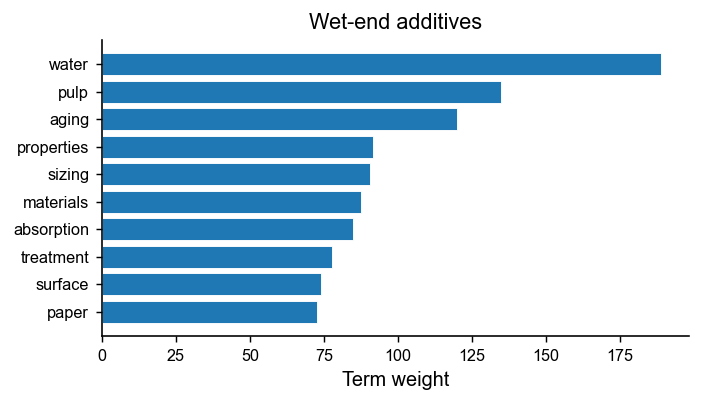

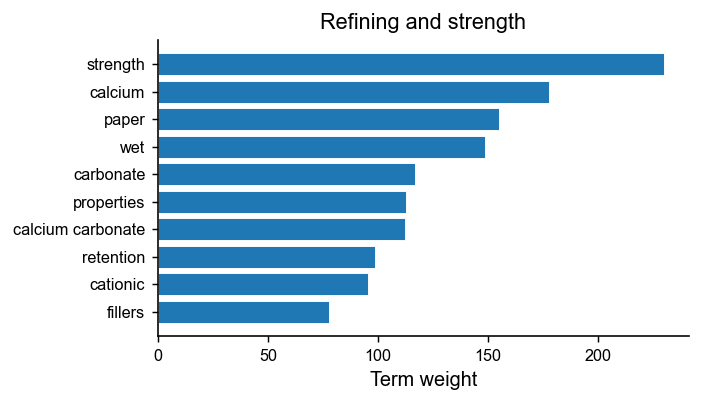

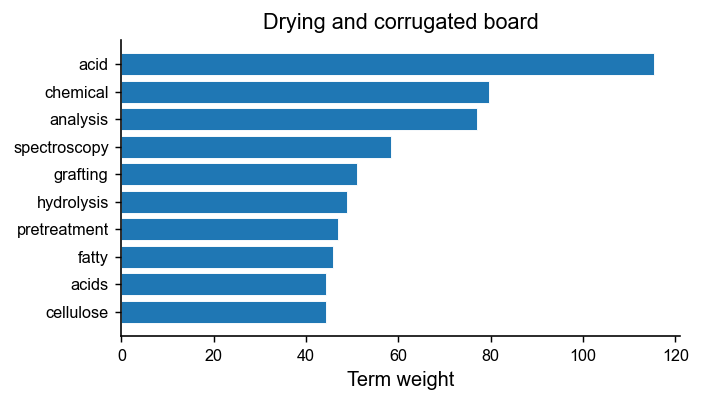

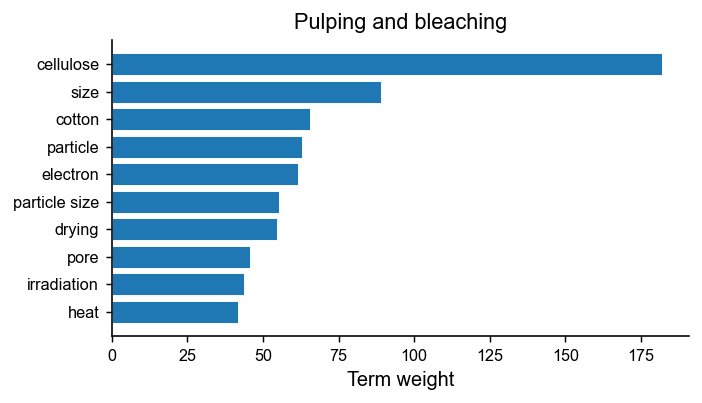

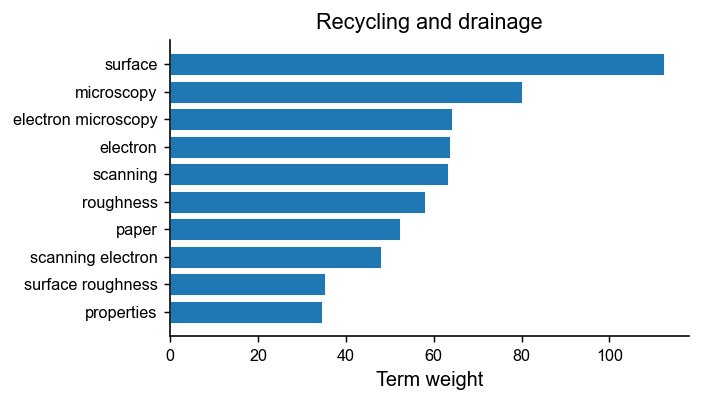

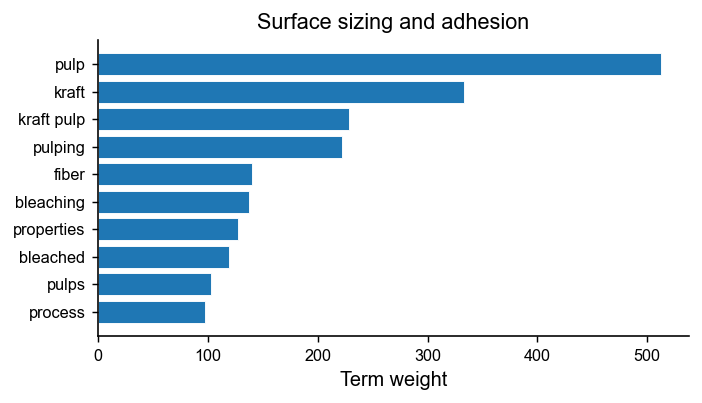

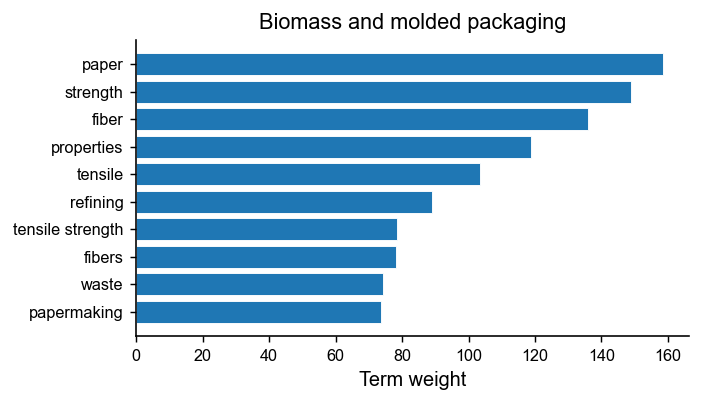

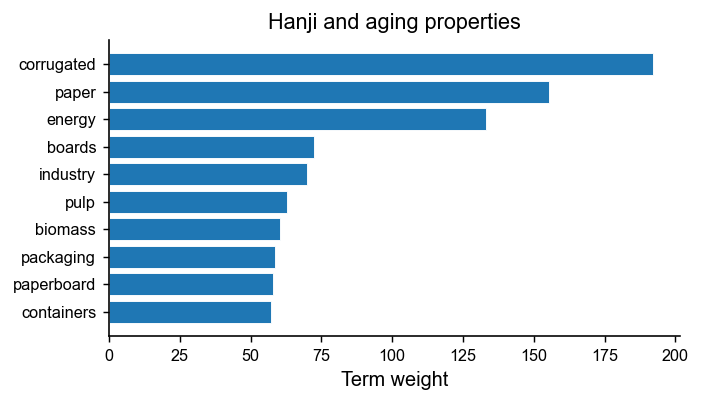

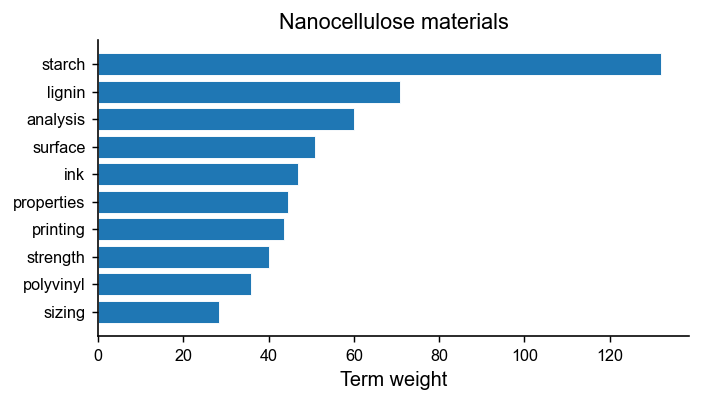

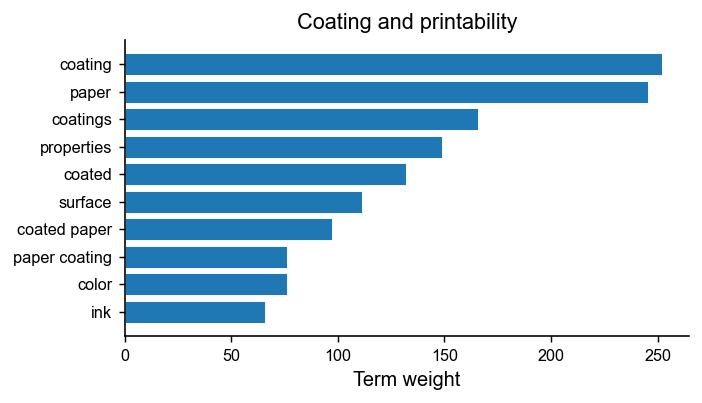

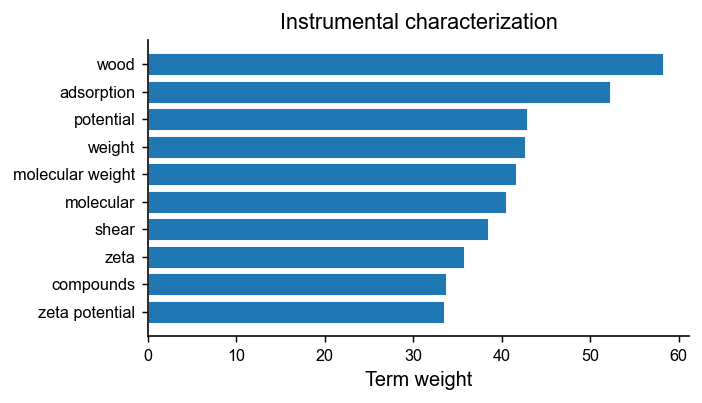

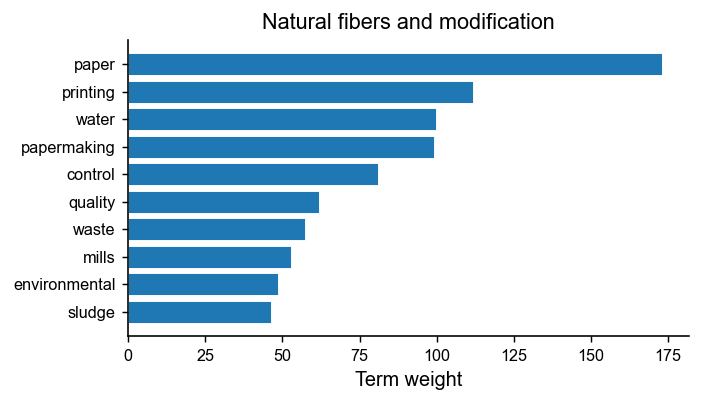

In [17]:
# Representative terms plot for each topic
for topic_id in range(1, FINAL_N_TOPICS + 1):
    temp = topic_terms_df[topic_terms_df["topic_id"] == topic_id].head(10).copy()
    temp = temp.sort_values("weight", ascending=True)

    fig, ax = plt.subplots(figsize=(5.5, 3.2))
    ax.barh(temp["term"], temp["weight"], edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Term weight", fontsize=11)
    ax.set_title(DEFAULT_TOPIC_LABELS.get(topic_id, f"Topic {topic_id}"), fontsize=12)
    ax.tick_params(labelsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    if SAVE_OUTPUTS:
        plt.savefig(FIGURES_DIR / f"fig_topic_{topic_id:02d}_representative_terms.png", dpi=600, bbox_inches="tight")
    plt.show()

## 8. Topic trends, life-cycle, and citation impact

,Year,dominant_topic,topic_label,n_documents,total_documents,proportion
0,2000,1,Wet-end additives,2,40,0.050
1,2000,2,Refining and strength,2,40,0.050
2,2000,3,Drying and corrugated board,1,40,0.025
3,2000,4,Pulping and bleaching,2,40,0.050
4,2000,5,Recycling and drainage,3,40,0.075


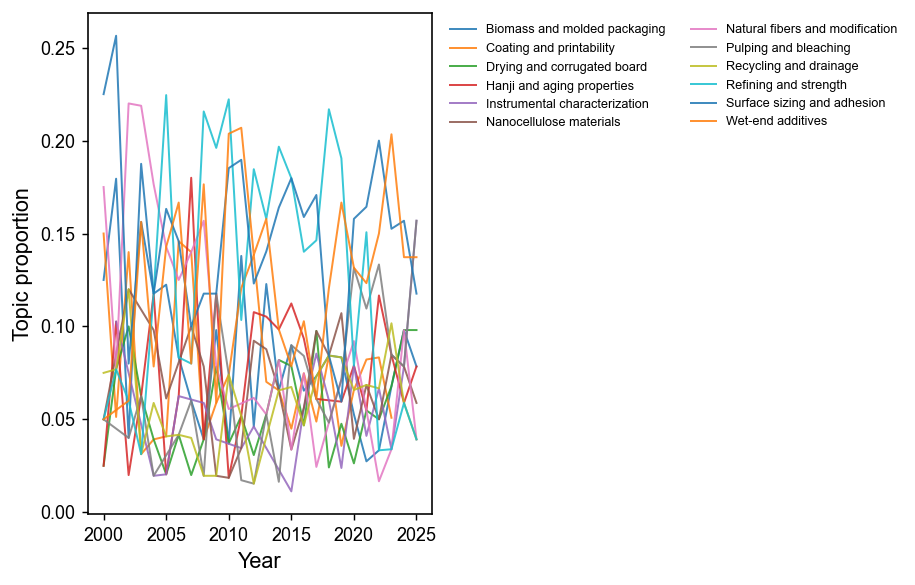

In [18]:
# Annual topic proportions
annual_topic = (
    df.groupby(["Year", "dominant_topic", "topic_label"])
    .size()
    .reset_index(name="n_documents")
)

annual_total = df.groupby("Year").size().reset_index(name="total_documents")
annual_topic = annual_topic.merge(annual_total, on="Year", how="left")
annual_topic["proportion"] = annual_topic["n_documents"] / annual_topic["total_documents"]

display(annual_topic.head())

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for label, sub in annual_topic.groupby("topic_label"):
    sub = sub.sort_values("Year")
    ax.plot(sub["Year"], sub["proportion"], linewidth=1.1, alpha=0.85, label=label)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Topic proportion", fontsize=12)
ax.tick_params(labelsize=10)
ax.legend(frameon=False, fontsize=7, ncol=2, bbox_to_anchor=(1.02, 1.0), loc="upper left")
plt.tight_layout()
if SAVE_OUTPUTS:
    plt.savefig(FIGURES_DIR / "fig_annual_topic_proportions.png", dpi=600, bbox_inches="tight")
    annual_topic.to_csv(RESULTS_DIR / "annual_topic_proportions.csv", index=False, encoding="utf-8-sig")
plt.show()

,topic_id,topic_label,slope_2000_2025,slope_x10-3_2000_2025,slope_2016_2025,slope_x10-3_2016_2025,topic_life_cycle
0,1,Wet-end additives,0.002600,2.600454,0.007274,7.274326,Hot topic
3,4,Pulping and bleaching,0.003683,3.682978,0.006809,6.808697,Hot topic
10,11,Instrumental characterization,0.002397,2.397121,0.004955,4.954892,Hot topic
2,3,Drying and corrugated board,0.000854,0.853891,0.004359,4.359167,Hot topic
5,6,Surface sizing and adhesion,-0.000861,-0.861430,0.001823,1.822889,Hot topic
7,8,Hanji and aging properties,0.000617,0.617209,0.000724,0.724218,Revived topic
6,7,Biomass and molded packaging,-0.002563,-2.562617,0.000201,0.201447,Stable or mature topic
11,12,Natural fibers and modification,-0.005567,-5.566799,-0.000470,-0.469588,Stable or mature topic
4,5,Recycling and drainage,0.000414,0.413934,-0.000779,-0.779142,Revived topic
8,9,Nanocellulose materials,0.001100,1.100260,-0.001512,-1.512336,Cold topic


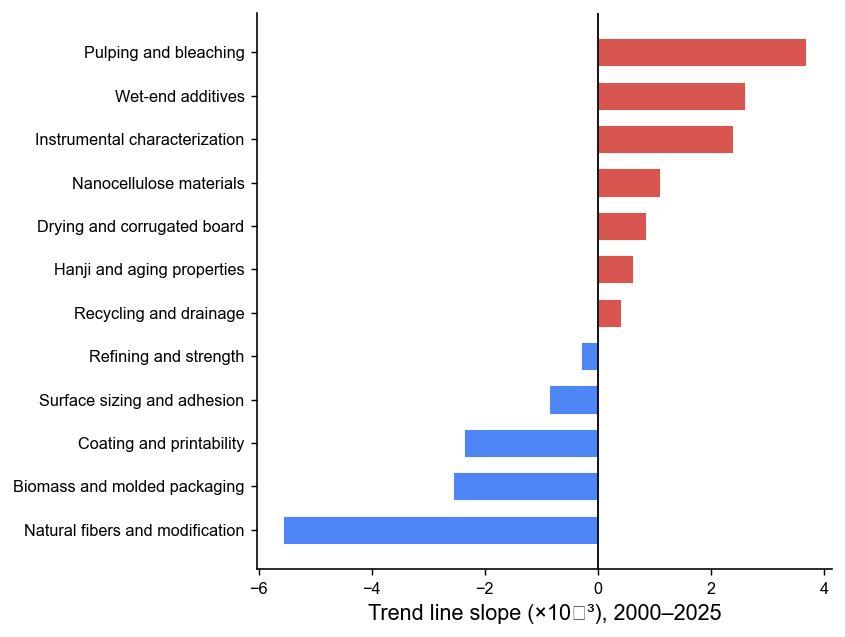

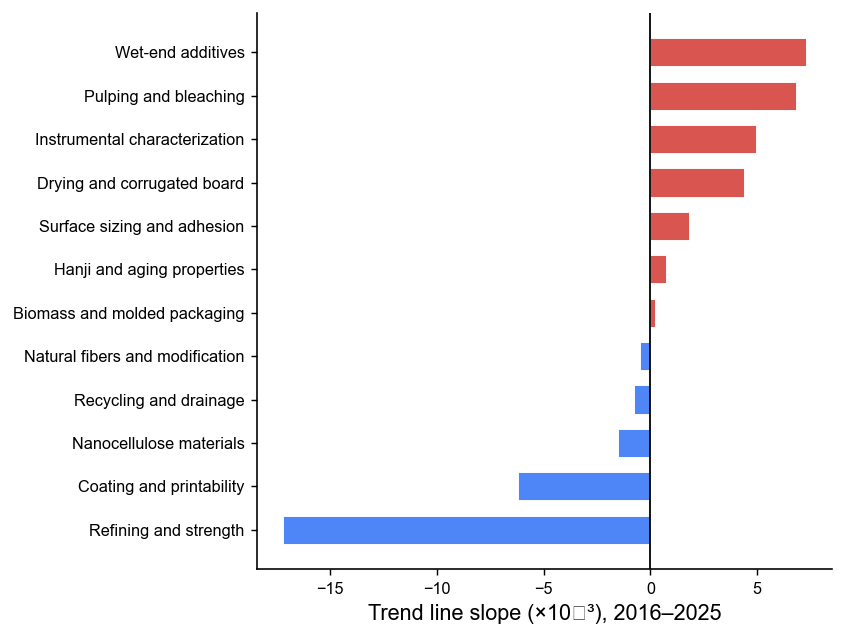

In [19]:
# Long-term and recent slopes
slope_rows = []

for (topic_id, label), sub in annual_topic.groupby(["dominant_topic", "topic_label"]):
    sub = sub.sort_values("Year").copy()

    # Fill missing years with zero proportions
    full_years = pd.DataFrame({"Year": np.arange(2000, 2026)})
    sub = full_years.merge(sub[["Year", "proportion"]], on="Year", how="left").fillna({"proportion": 0})

    x_long = sub["Year"].values
    y_long = sub["proportion"].values

    long_slope = np.polyfit(x_long, y_long, 1)[0] if len(sub) >= 2 else np.nan

    recent = sub[sub["Year"] >= 2016]
    recent_slope = np.polyfit(recent["Year"], recent["proportion"], 1)[0] if len(recent) >= 2 else np.nan

    early_mean = sub[sub["Year"] <= 2015]["proportion"].mean()
    recent_mean = sub[sub["Year"] >= 2021]["proportion"].mean()

    if recent_slope > 0.001 and early_mean < 0.02:
        lifecycle = "Emerging topic"
    elif recent_slope > 0.001:
        lifecycle = "Hot topic"
    elif recent_slope < -0.001:
        lifecycle = "Cold topic"
    elif recent_mean > early_mean:
        lifecycle = "Revived topic"
    else:
        lifecycle = "Stable or mature topic"

    slope_rows.append({
        "topic_id": topic_id,
        "topic_label": label,
        "slope_2000_2025": long_slope,
        "slope_x10-3_2000_2025": long_slope * 1000,
        "slope_2016_2025": recent_slope,
        "slope_x10-3_2016_2025": recent_slope * 1000,
        "topic_life_cycle": lifecycle
    })

topic_slopes = pd.DataFrame(slope_rows).sort_values("slope_2016_2025", ascending=False)
display(topic_slopes)

def plot_slope(df_in, slope_col, xlabel):
    temp = df_in.sort_values(slope_col, ascending=True).copy()
    colors = temp[slope_col].apply(lambda x: "#d95550" if x > 0 else "#4f86f7")

    fig, ax = plt.subplots(figsize=(6.6, 5.0))
    ax.barh(temp["topic_label"], temp[slope_col], color=colors, edgecolor="white", linewidth=0.5, height=0.65)
    ax.axvline(0, color="black", linewidth=1.0)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.tick_params(axis="both", labelsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_slope(topic_slopes, "slope_x10-3_2000_2025", "Trend line slope (×10⁻³), 2000–2025")
plot_slope(topic_slopes, "slope_x10-3_2016_2025", "Trend line slope (×10⁻³), 2016–2025")

if SAVE_OUTPUTS:
    topic_slopes.to_csv(RESULTS_DIR / "topic_slope_lifecycle_summary.csv", index=False, encoding="utf-8-sig")

,dominant_topic,topic_label,n_documents,mean_citations_per_document_per_year,median_citations_per_document_per_year,slope_x10-3_2016_2025,topic_life_cycle
3,4,Pulping and bleaching,104,0.420625,0.254011,6.808697,Hot topic
10,11,Instrumental characterization,67,0.340077,0.125000,4.954892,Hot topic
4,5,Recycling and drainage,92,0.321507,0.146429,-0.779142,Revived topic
8,9,Nanocellulose materials,100,0.321452,0.177083,-1.512336,Cold topic
0,1,Wet-end additives,193,0.301413,0.200000,7.274326,Hot topic
2,3,Drying and corrugated board,87,0.287024,0.166667,4.359167,Hot topic
7,8,Hanji and aging properties,122,0.281817,0.181818,0.724218,Revived topic
1,2,Refining and strength,209,0.277987,0.181818,-17.187294,Cold topic
5,6,Surface sizing and adhesion,231,0.276030,0.176471,1.822889,Hot topic
9,10,Coating and printability,112,0.240060,0.153846,-6.197276,Cold topic


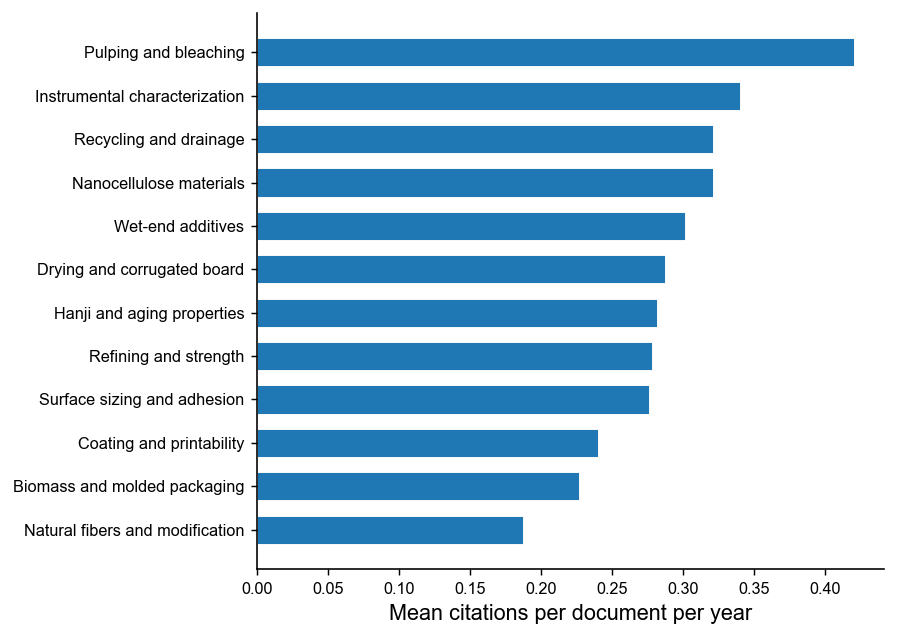

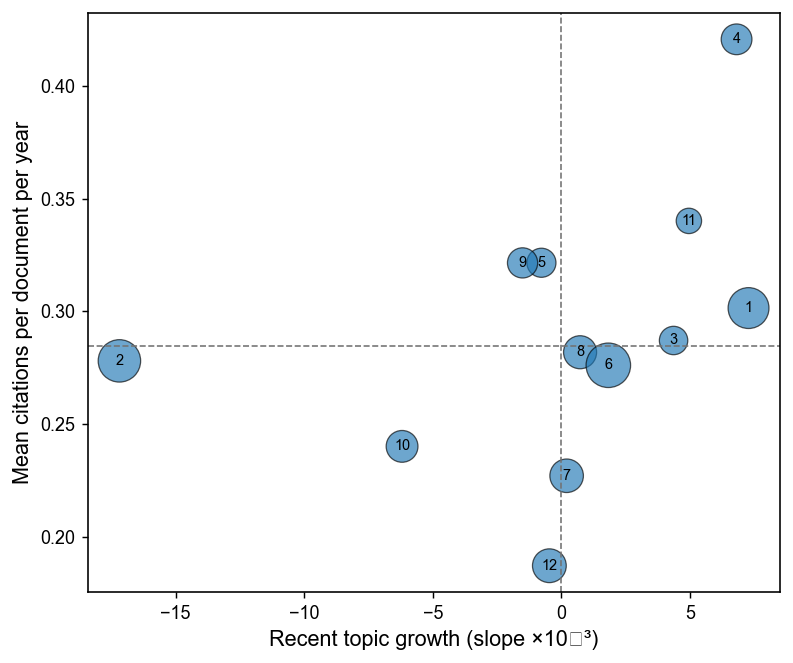

In [20]:
# Topic-level citation impact
df["citation_age_years"] = (2026 - df["Year"]).clip(lower=1)
df["citations_per_year"] = df["Cited by"] / df["citation_age_years"]

citation_impact = (
    df.groupby(["dominant_topic", "topic_label"])
    .agg(
        n_documents=("Title", "count"),
        mean_citations_per_document_per_year=("citations_per_year", "mean"),
        median_citations_per_document_per_year=("citations_per_year", "median")
    )
    .reset_index()
)

citation_impact = citation_impact.merge(
    topic_slopes[["topic_id", "slope_x10-3_2016_2025", "topic_life_cycle"]],
    left_on="dominant_topic",
    right_on="topic_id",
    how="left"
).drop(columns=["topic_id"])

citation_impact = citation_impact.sort_values("mean_citations_per_document_per_year", ascending=False)
display(citation_impact)

# Fig. 8a
temp = citation_impact.sort_values("mean_citations_per_document_per_year", ascending=True)

fig, ax = plt.subplots(figsize=(7.0, 5.0))
ax.barh(
    temp["topic_label"],
    temp["mean_citations_per_document_per_year"],
    edgecolor="white",
    linewidth=0.5,
    height=0.65
)
ax.set_xlabel("Mean citations per document per year", fontsize=12)
ax.tick_params(axis="both", labelsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
if SAVE_OUTPUTS:
    plt.savefig(FIGURES_DIR / "fig_topic_citation_impact.png", dpi=600, bbox_inches="tight")
plt.show()

# Fig. 8b
fig, ax = plt.subplots(figsize=(6.2, 5.2))
sizes = 30 + citation_impact["n_documents"] * 2.5

ax.scatter(
    citation_impact["slope_x10-3_2016_2025"],
    citation_impact["mean_citations_per_document_per_year"],
    s=sizes,
    alpha=0.65,
    edgecolor="black",
    linewidth=0.7
)

ax.axvline(0, color="0.45", linestyle="--", linewidth=0.9)
ax.axhline(citation_impact["mean_citations_per_document_per_year"].median(), color="0.45", linestyle="--", linewidth=0.9)

for _, row in citation_impact.iterrows():
    ax.text(
        row["slope_x10-3_2016_2025"],
        row["mean_citations_per_document_per_year"],
        str(int(row["dominant_topic"])),
        ha="center",
        va="center",
        fontsize=8
    )

ax.set_xlabel("Recent topic growth (slope ×10⁻³)", fontsize=12)
ax.set_ylabel("Mean citations per document per year", fontsize=12)
ax.tick_params(labelsize=10)
plt.tight_layout()
if SAVE_OUTPUTS:
    plt.savefig(FIGURES_DIR / "fig_growth_impact_positioning.png", dpi=600, bbox_inches="tight")
    citation_impact.to_csv(RESULTS_DIR / "topic_citation_growth_impact.csv", index=False, encoding="utf-8-sig")
plt.show()

## 9. Supplementary tables for GitHub and reviewer response

The following tables are useful as supplementary data:

- synonym merging list;
- representative LDA terms for each topic;
- keyword community summary;
- centrality rankings;
- topic trend and citation-impact summaries.

In [21]:
synonym_rows = [{"Original term": k, "Merged term": v} for k, v in synonym_map.items()]
for pat in [
    "nanofibril", "cellulose nanofibrils", "CNF", "cellulose nanocrystals",
    "CNC", "cellulose nanomaterials", "nanofibrillated cellulose",
    "microfibrillated cellulose", "cellulose nanofibers"
]:
    synonym_rows.append({"Original term": pat, "Merged term": "nanocellulose"})

synonym_table = pd.DataFrame(synonym_rows).drop_duplicates().sort_values(["Merged term", "Original term"])

print("Supplementary synonym merging list")
display(synonym_table)

print("Supplementary LDA topic representative terms")
display(topic_terms_df)

print("Supplementary keyword community summary")
display(community_summary)

if SAVE_OUTPUTS:
    synonym_table.to_csv(RESULTS_DIR / "supplementary_synonym_merging_list.csv", index=False, encoding="utf-8-sig")
    topic_terms_df.to_csv(RESULTS_DIR / "supplementary_lda_representative_terms.csv", index=False, encoding="utf-8-sig")
    community_summary.to_csv(RESULTS_DIR / "supplementary_keyword_community_summary.csv", index=False, encoding="utf-8-sig")

Supplementary synonym merging list


,Original term,Merged term
32,bleached kraft pulps,bleached kraft pulp
24,carboxy methyl cellulose,carboxymethyl cellulose
23,carboxymethylcellulose,carboxymethyl cellulose
22,cmc,carboxymethyl cellulose
26,cellulose films,cellulose film
41,coated papers,coated paper
39,coating,coatings
42,eco friendly,eco-friendly
43,environmentally friendly,eco-friendly
40,filler,fillers


Supplementary LDA topic representative terms


,topic_id,rank,term,weight
0,1,1,water,188.855156
1,1,2,pulp,134.971555
2,1,3,aging,119.960630
3,1,4,properties,91.632418
4,1,5,sizing,90.691876
...,...,...,...,...
235,12,16,recycling,39.185083
236,12,17,wastewater,39.083325
237,12,18,papers,38.060356
238,12,19,materials,36.157421


Supplementary keyword community summary


,community_id,n_keywords,top_keywords,top5_keywords
0,1,103,kraft pulp; nanocellulose; refining; particle ...,kraft pulp; nanocellulose; refining; particle ...
1,2,101,tensile strength; papermaking; optical propert...,tensile strength; papermaking; optical propert...
2,3,78,lignin; hanji; plants; bast fibers; paper mulb...,lignin; hanji; plants; bast fibers; paper mulb...
3,4,70,coatings; coated paper; mixing; color; surface...,coatings; coated paper; mixing; color; surface...
4,5,59,recycling; waste paper; corrugated containers;...,recycling; waste paper; corrugated containers;...
5,6,31,packaging; pulp materials; biomass; water abso...,packaging; pulp materials; biomass; water abso...
6,7,15,chlorine compounds; hydrophobicity; grafting; ...,chlorine compounds; hydrophobicity; grafting; ...
7,8,6,paper industries; paper industry; pulp industr...,paper industries; paper industry; pulp industr...
8,9,2,chemistry; materials science,chemistry; materials science
